In [1]:
import pandas as pd

ratings =pd.read_csv('/Users/shshank/Documents/Project/Movie Recommender/ml-latest-small/ratings.csv') 

In [2]:
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [3]:
ratings = ratings.drop('timestamp', axis=1)
ratings.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [4]:
movies = pd.read_csv('/Users/shshank/Documents/Project/Movie Recommender/ml-latest-small/movies.csv')
links = pd.read_csv('/Users/shshank/Documents/Project/Movie Recommender/ml-latest-small/links.csv')

In [5]:
ratings_movies_merged = pd.merge(ratings, movies, on='movieId', how='inner')

In [6]:
data_merged = pd.merge(ratings_movies_merged, links, on='movieId', how='inner')

In [7]:
data_merged

,userId,movieId,rating,title,genres,imdbId,tmdbId
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
2,1,6,4.0,Heat (1995),Action|Crime|Thriller,113277,949.0
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0
...,...,...,...,...,...,...,...
100831,610,166534,4.0,Split (2017),Drama|Horror|Thriller,4972582,381288.0
100832,610,168248,5.0,John Wick: Chapter Two (2017),Action|Crime|Thriller,4425200,324552.0
100833,610,168250,5.0,Get Out (2017),Horror,5052448,419430.0
100834,610,168252,5.0,Logan (2017),Action|Sci-Fi,3315342,263115.0


In [8]:
 data_merged.to_csv('movie_data.csv', index=False, encoding='utf-8')

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Set style for prettier plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")


Libraries imported successfully!
PyTorch version: 2.7.1


Dataset Overview:
Shape: (100836, 7)
Columns: ['userId', 'movieId', 'rating', 'title', 'genres', 'imdbId', 'tmdbId']

First few rows:
   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
1       1        3     4.0      Grumpier Old Men (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   

                                        genres  imdbId   tmdbId  
0  Adventure|Animation|Children|Comedy|Fantasy  114709    862.0  
1                               Comedy|Romance  113228  15602.0  
2                        Action|Crime|Thriller  113277    949.0  
3                             Mystery|Thriller  114369    807.0  
4                       Crime|Mystery|Thriller  114814    629.0  

Unique users: 610
Unique movies: 9724
Rating range: 0.5 to 5.0
Average rating: 3.50


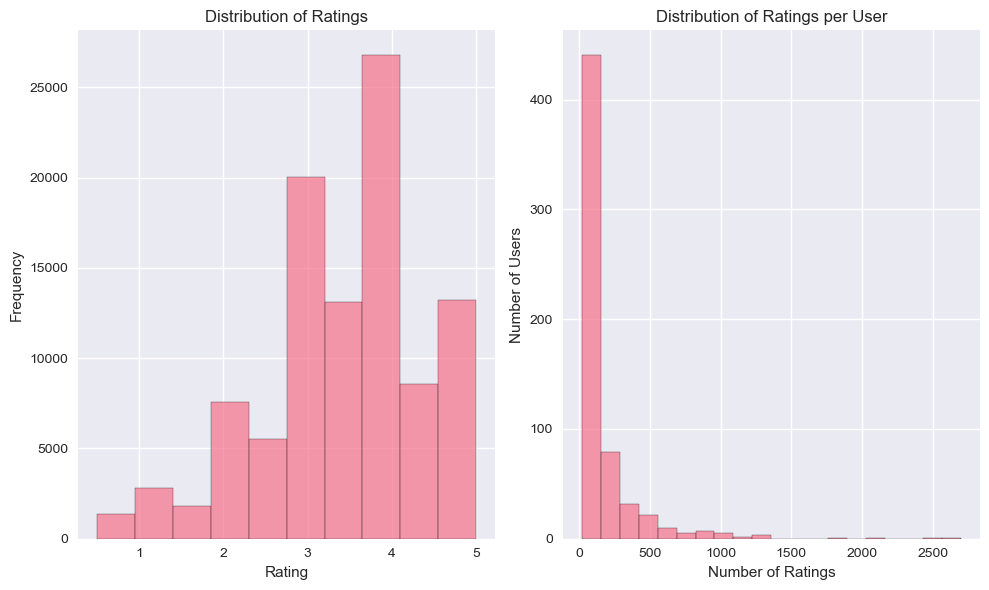

In [10]:
# Load your data (replace with your actual data loading)
df = pd.read_csv('movie_data.csv')

# For now, let's assume your data is already loaded as 'df'
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

print(f"\nUnique users: {df['userId'].nunique()}")
print(f"Unique movies: {df['movieId'].nunique()}")
print(f"Rating range: {df['rating'].min()} to {df['rating'].max()}")
print(f"Average rating: {df['rating'].mean():.2f}")

# Plot rating distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
df['rating'].hist(bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
user_counts = df['userId'].value_counts()
plt.hist(user_counts, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()


In [11]:
def preprocess_data(df):
    """
    Create user and movie ID mappings for neural network
    """
    # Create mappings from original IDs to continuous indices
    unique_users = sorted(df['userId'].unique())
    unique_movies = sorted(df['movieId'].unique())
    
    user_to_idx = {user_id: idx for idx, user_id in enumerate(unique_users)}
    movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(unique_movies)}
    
    # Reverse mappings for later use
    idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
    idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}
    
    # Apply mappings
    df_processed = df.copy()
    df_processed['user_idx'] = df_processed['userId'].map(user_to_idx)
    df_processed['movie_idx'] = df_processed['movieId'].map(movie_to_idx)
    
    return df_processed, user_to_idx, movie_to_idx, idx_to_user, idx_to_movie

# Preprocess the data
df_processed, user_to_idx, movie_to_idx, idx_to_user, idx_to_movie = preprocess_data(df)

num_users = len(user_to_idx)
num_movies = len(movie_to_idx)

print(f"Processed data shape: {df_processed.shape}")
print(f"Number of users: {num_users}")
print(f"Number of movies: {num_movies}")
print(f"Sparsity: {(1 - len(df_processed) / (num_users * num_movies)) * 100:.2f}%")


Processed data shape: (100836, 9)
Number of users: 610
Number of movies: 9724
Sparsity: 98.30%


Data Split Summary:
Training set: 80183 ratings (79.5%)
Validation set: 10295 ratings (10.2%)
Test set: 10358 ratings (10.3%)


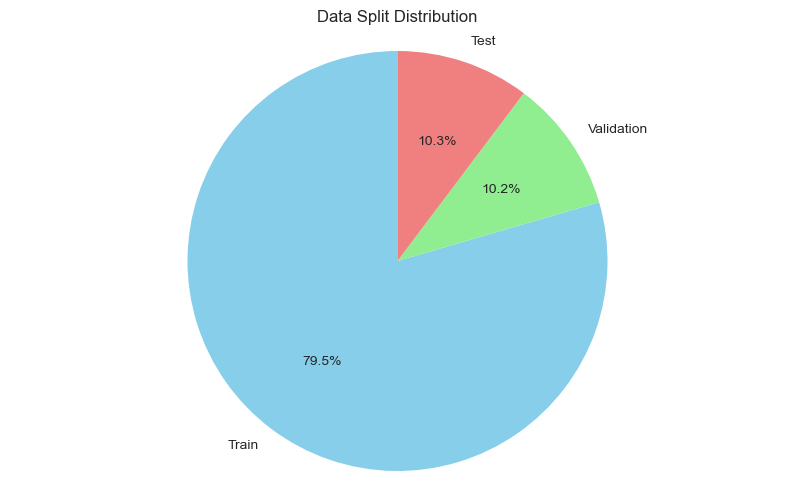

In [12]:
def split_recommender_data(df, test_size=0.1, val_size=0.1, random_state=42):
    """
    Split data ensuring each user appears in train/val/test sets
    """
    train_data = []
    val_data = []
    test_data = []
    
    np.random.seed(random_state)
    
    for user_id in df['user_idx'].unique():
        user_ratings = df[df['user_idx'] == user_id].copy()
        
        # Skip users with too few ratings
        if len(user_ratings) < 3:
            train_data.append(user_ratings)
            continue
        
        # Shuffle user's ratings
        user_ratings = user_ratings.sample(frac=1, random_state=random_state).reset_index(drop=True)
        
        # Calculate split indices
        n_ratings = len(user_ratings)
        test_idx = int(n_ratings * (1 - test_size)) # Test gets last 10%
        val_idx = int(test_idx * (1 - val_size / (1 - test_size))) # Val from remaining
        
        # Split the data
        train_user = user_ratings[:val_idx] 
        val_user = user_ratings[val_idx:test_idx]
        test_user = user_ratings[test_idx:]
        
        train_data.append(train_user)
        if len(val_user) > 0:
            val_data.append(val_user)
        if len(test_user) > 0:
            test_data.append(test_user)
    
    # Combine all splits
    train_df = pd.concat(train_data, ignore_index=True)
    val_df = pd.concat(val_data, ignore_index=True) if val_data else pd.DataFrame()
    test_df = pd.concat(test_data, ignore_index=True) if test_data else pd.DataFrame()
    
    return train_df, val_df, test_df

# Split the data
train_df, val_df, test_df = split_recommender_data(df_processed)

print("Data Split Summary:")
print(f"Training set: {len(train_df)} ratings ({len(train_df)/len(df_processed)*100:.1f}%)")
print(f"Validation set: {len(val_df)} ratings ({len(val_df)/len(df_processed)*100:.1f}%)")
print(f"Test set: {len(test_df)} ratings ({len(test_df)/len(df_processed)*100:.1f}%)")

# Visualize the split
plt.figure(figsize=(10, 6))
split_data = [len(train_df), len(val_df), len(test_df)]
labels = ['Train', 'Validation', 'Test']
colors = ['skyblue', 'lightgreen', 'lightcoral']

plt.pie(split_data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Data Split Distribution')
plt.axis('equal')
plt.show()


In [13]:
class MovieDataset(Dataset):
    def __init__(self, df):
        # Converts columns to PyTorch tensors:
        self.users = torch.LongTensor(df['user_idx'].values)
        self.movies = torch.LongTensor(df['movie_idx'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)
        
    def __len__(self):
        # Returns total number of ratings in the dataset
        return len(self.ratings)
    
    def __getitem__(self, idx):
        # Returns one sample at the given index
        return self.users[idx], self.movies[idx], self.ratings[idx]

# Create datasets
# After Train The splitting logic reserves test data first:
    # test_idx = int(n_ratings * (1 - test_size))  # Test gets last 10%
    # val_idx = int(test_idx * (1 - val_size / (1 - test_size)))  # Val from remaining


train_dataset = MovieDataset(train_df)
val_dataset = MovieDataset(val_df) if len(val_df) > 0 else None # Validation is calculated from what's left after test
test_dataset = MovieDataset(test_df) # Test set is calculated directly from total ratings

# Create data loaders
# Training batches: 157
# Validation batches: 21  
# Test batches: 21
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset else None
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader) if val_loader else 0}")
print(f"Test batches: {len(test_loader)}")


Training batches: 157
Validation batches: 21
Test batches: 21


In [25]:
class ItemBasedNCF(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=64, hidden_dims=[128, 64, 32]):
        super(ItemBasedNCF, self).__init__()
        
        # Embedding layers
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)
        
        # Bias terms
        self.user_bias = nn.Embedding(num_users, 1)
        self.movie_bias = nn.Embedding(num_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        
       # Neural network layers
        layers = []
        input_dim = embedding_dim * 2  # User + Movie embeddings concatenated
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(0.3)
            ])
            input_dim = hidden_dim
        
        # Final prediction layer
        layers.append(nn.Linear(input_dim, 1))
        
        self.neural_layers = nn.Sequential(*layers)
        
        # Initialize embeddings with smaller values
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.movie_embedding.weight, std=0.01)
        nn.init.normal_(self.user_bias.weight, std=0.01)
        nn.init.normal_(self.movie_bias.weight, std=0.01)
    
    def forward(self, user_ids, movie_ids):
        # Get embeddings
        user_embed = self.user_embedding(user_ids)
        movie_embed = self.movie_embedding(movie_ids)
        
        # Get bias terms
        user_bias = self.user_bias(user_ids).squeeze()
        movie_bias = self.movie_bias(movie_ids).squeeze()
        
        # Concatenate embeddings for neural network
        x = torch.cat([user_embed, movie_embed], dim=1)
        
        # Pass through neural network
        neural_output = self.neural_layers(x).squeeze()
        
        # Combine neural output with bias terms
        prediction = neural_output + user_bias + movie_bias + self.global_bias
        
        # Clamp predictions to valid rating range
        prediction = torch.clamp(prediction, 0.5, 5.0)
        
        return prediction

# Create model
model = ItemBasedNCF(num_users, num_movies, embedding_dim=64)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print(model)


Model created with 699040 parameters
ItemBasedNCF(
  (user_embedding): Embedding(610, 64)
  (movie_embedding): Embedding(9724, 64)
  (user_bias): Embedding(610, 1)
  (movie_bias): Embedding(9724, 1)
  (neural_layers): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [15]:
# Check if MPS is available and set device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Using MPS device (Apple Silicon GPU)!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 Using CUDA device!")
else:
    device = torch.device("cpu")
    print("💻 Using CPU device")

print(f"Selected device: {device}")

# Test MPS functionality
if device.type == 'mps':
    test_tensor = torch.randn(10, 10).to(device)
    print(f"MPS test successful! Tensor device: {test_tensor.device}")
    
    # Clear any existing cache
    torch.mps.empty_cache()
    print("MPS cache cleared and ready!")

🚀 Using MPS device (Apple Silicon GPU)!
Selected device: mps
MPS test successful! Tensor device: mps:0
MPS cache cleared and ready!


In [16]:
def calculate_metrics(predictions, targets):
    """Calculate various accuracy metrics - MPS compatible"""
    # Move tensors to CPU for numpy operations (MPS tensors need to be moved to CPU first)
    predictions_np = predictions.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()
    
    mse = mean_squared_error(targets_np, predictions_np)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(targets_np, predictions_np)
    
    # Calculate accuracy within different thresholds
    accuracy_05 = np.mean(np.abs(predictions_np - targets_np) <= 0.5) * 100
    accuracy_10 = np.mean(np.abs(predictions_np - targets_np) <= 1.0) * 100
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Accuracy_0.5': accuracy_05,
        'Accuracy_1.0': accuracy_10
    }

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch - MPS compatible"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    for batch_idx, (user_ids, movie_ids, ratings) in enumerate(train_loader):
        # Move data to device (MPS/CUDA/CPU)
        user_ids = user_ids.to(device, non_blocking=True)
        movie_ids = movie_ids.to(device, non_blocking=True)
        ratings = ratings.to(device, non_blocking=True)
        
        optimizer.zero_grad() # Clears gradients from previous batch
        
        predictions = model(user_ids, movie_ids)
        loss = criterion(predictions, ratings)
        
        loss.backward() # Backward pass
        optimizer.step() # Updates weight
        
        total_loss += loss.item()
        # Keep predictions and targets on device for now
        all_predictions.append(predictions.detach())
        all_targets.append(ratings.detach())
        
        # Clear MPS cache periodically to prevent memory issues
        if device.type == 'mps' and batch_idx % 100 == 0:
            torch.mps.empty_cache()
    
    # Concatenate all predictions and targets
    all_predictions = torch.cat(all_predictions)
    all_targets = torch.cat(all_targets)
    
    # Calculate metrics (this will move data to CPU inside the function)
    metrics = calculate_metrics(all_predictions, all_targets)
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss, metrics

def evaluate(model, data_loader, criterion, device):
    """Evaluate model on validation/test set - MPS compatible"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch_idx, (user_ids, movie_ids, ratings) in enumerate(data_loader):
            # Move data to device
            user_ids = user_ids.to(device, non_blocking=True)
            movie_ids = movie_ids.to(device, non_blocking=True)
            ratings = ratings.to(device, non_blocking=True)
            
            predictions = model(user_ids, movie_ids)
            loss = criterion(predictions, ratings)
            
            total_loss += loss.item()
            all_predictions.append(predictions)
            all_targets.append(ratings)
            
            # Clear MPS cache periodically
            if device.type == 'mps' and batch_idx % 50 == 0:
                torch.mps.empty_cache()
    
    # Concatenate all predictions and targets
    all_predictions = torch.cat(all_predictions)
    all_targets = torch.cat(all_targets)
    
    # Calculate metrics
    metrics = calculate_metrics(all_predictions, all_targets)
    
    avg_loss = total_loss / len(data_loader)
    return avg_loss, metrics, all_predictions, all_targets


In [17]:
def train_model(model, train_loader, val_loader, device, num_epochs=100, lr=0.001, patience=10):
    """Train the model with MPS support and memory management"""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Storage for metrics
    history = {
        'train_loss': [], 'val_loss': [],
        'train_rmse': [], 'val_rmse': [],
        'train_mae': [], 'val_mae': [],
        'train_acc_05': [], 'val_acc_05': [],
        'train_acc_10': [], 'val_acc_10': []
    }
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"Starting training on {device}...")
    print("-" * 80)
    
    # Move model to device
    model = model.to(device)
    print(f"Model moved to {device}")
    
    for epoch in range(num_epochs):
        # Clear MPS cache at the beginning of each epoch
        if device.type == 'mps':
            torch.mps.empty_cache()
        
        # Training - pass device to functions
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        if val_loader:
            val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device)
        else:
            val_loss, val_metrics = train_loss, train_metrics
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Store metrics
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_rmse'].append(train_metrics['RMSE'])
        history['val_rmse'].append(val_metrics['RMSE'])
        history['train_mae'].append(train_metrics['MAE'])
        history['val_mae'].append(val_metrics['MAE'])
        history['train_acc_05'].append(train_metrics['Accuracy_0.5'])
        history['val_acc_05'].append(val_metrics['Accuracy_0.5'])
        history['train_acc_10'].append(train_metrics['Accuracy_1.0'])
        history['val_acc_10'].append(val_metrics['Accuracy_1.0'])
        
        # Print progress
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:3d} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train RMSE: {train_metrics['RMSE']:.4f} | Val RMSE: {val_metrics['RMSE']:.4f} | "
                  f"Val Acc(±0.5): {val_metrics['Accuracy_0.5']:.1f}%")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model (move to CPU before saving to avoid device issues)
            model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            torch.save(model_state, 'best_model.pth')
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break
    
    # Load best model and move back to device
    checkpoint = torch.load('best_model.pth')
    model.load_state_dict(checkpoint)
    model = model.to(device)
    
    # Final memory cleanup
    if device.type == 'mps':
        torch.mps.empty_cache()
        print("Final MPS cache cleanup completed!")
    
    return history

# Train the model with MPS support
print("Initializing training with MPS device...")
history = train_model(model, train_loader, val_loader, device, num_epochs=100, lr=0.001)


Initializing training with MPS device...
Starting training on mps...
--------------------------------------------------------------------------------
Model moved to mps
Epoch   0 | Train Loss: 5.3461 | Val Loss: 2.6725 | Train RMSE: 2.3134 | Val RMSE: 1.5181 | Val Acc(±0.5): 36.9%
Epoch  10 | Train Loss: 0.6859 | Val Loss: 0.8162 | Train RMSE: 0.8281 | Val RMSE: 0.9103 | Val Acc(±0.5): 45.9%

Early stopping at epoch 19
Final MPS cache cleanup completed!


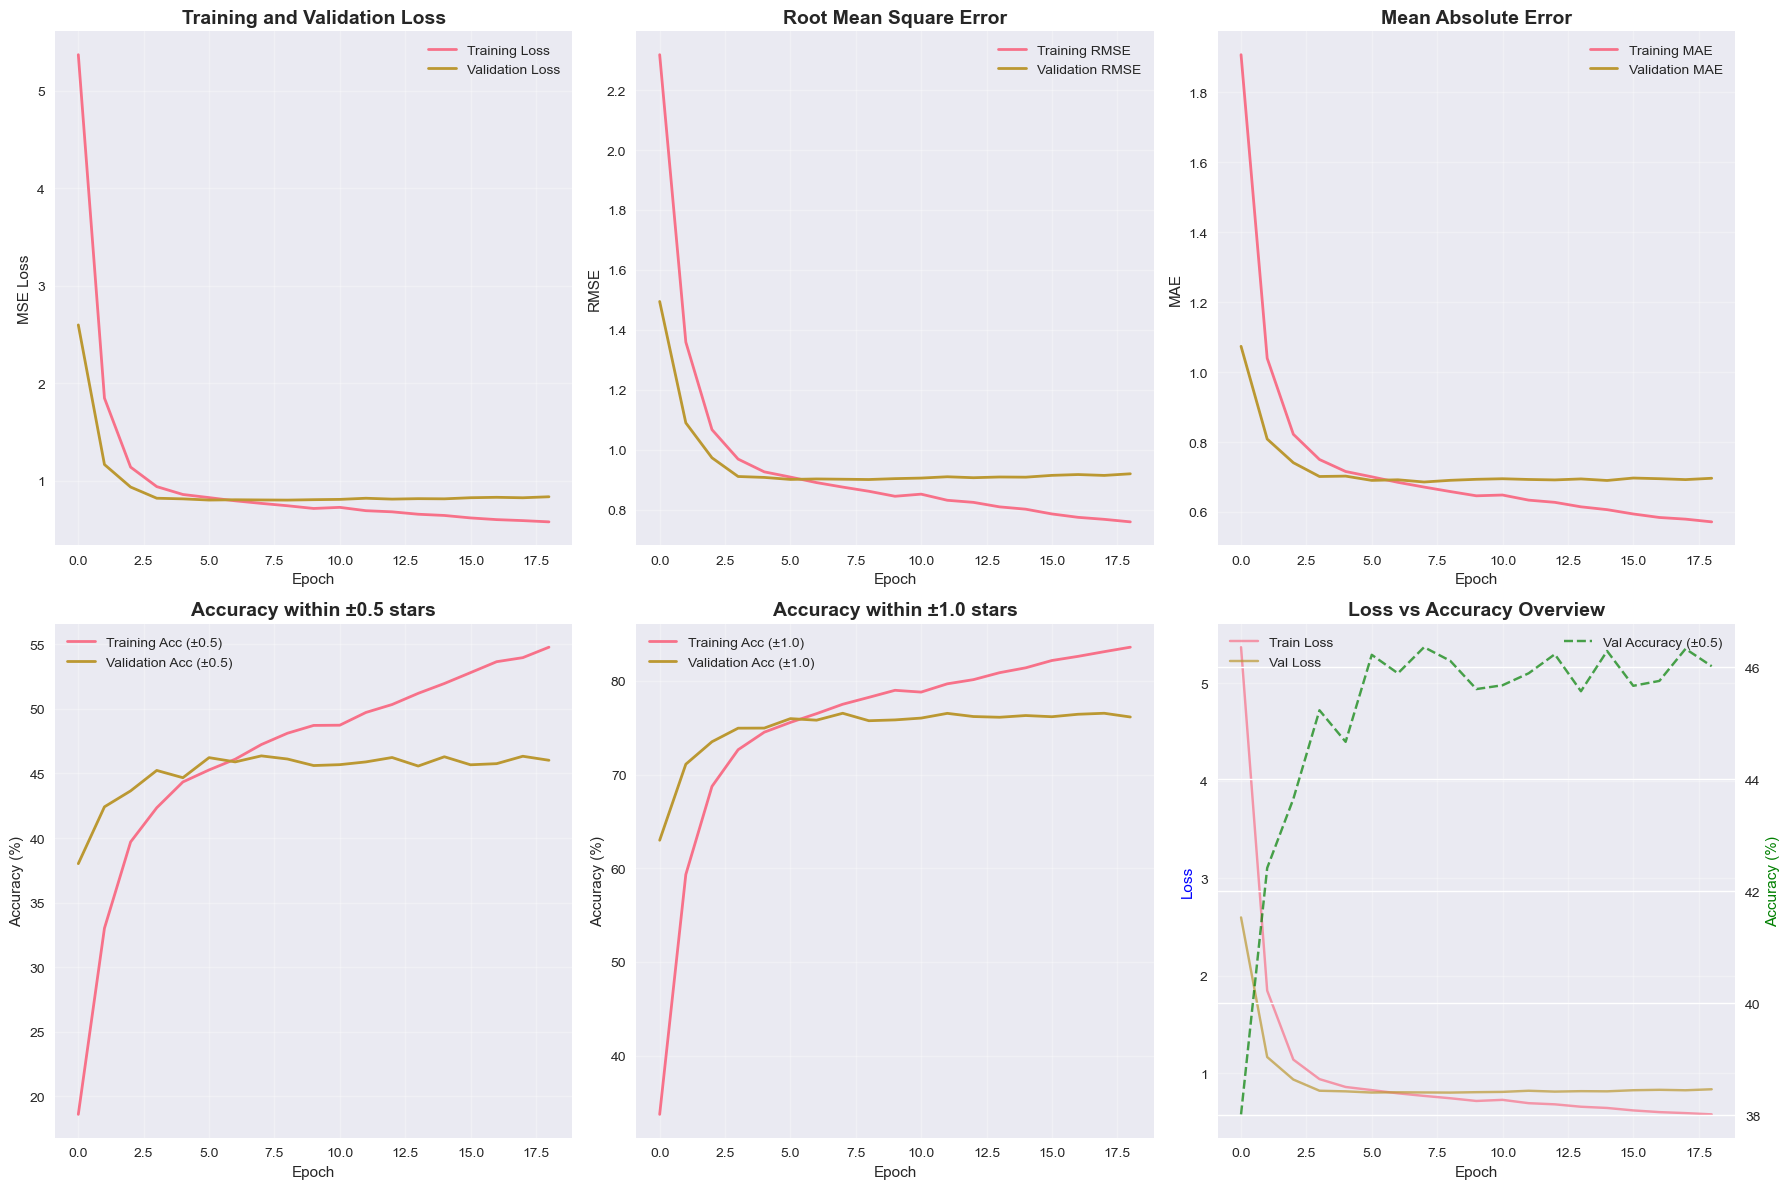

In [37]:
def plot_training_history(history):
    """Plot comprehensive training history"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Loss plot
    axes[0, 0].plot(history['train_loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # RMSE plot
    axes[0, 1].plot(history['train_rmse'], label='Training RMSE', linewidth=2)
    axes[0, 1].plot(history['val_rmse'], label='Validation RMSE', linewidth=2)
    axes[0, 1].set_title('Root Mean Square Error', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('RMSE')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # MAE plot
    axes[0, 2].plot(history['train_mae'], label='Training MAE', linewidth=2)
    axes[0, 2].plot(history['val_mae'], label='Validation MAE', linewidth=2)
    axes[0, 2].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('MAE')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Accuracy ±0.5 plot
    axes[1, 0].plot(history['train_acc_05'], label='Training Acc (±0.5)', linewidth=2)
    axes[1, 0].plot(history['val_acc_05'], label='Validation Acc (±0.5)', linewidth=2)
    axes[1, 0].set_title('Accuracy within ±0.5 stars', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Accuracy ±1.0 plot
    axes[1, 1].plot(history['train_acc_10'], label='Training Acc (±1.0)', linewidth=2)
    axes[1, 1].plot(history['val_acc_10'], label='Validation Acc (±1.0)', linewidth=2)
    axes[1, 1].set_title('Accuracy within ±1.0 stars', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning curve comparison
    epochs = range(len(history['train_loss']))
    axes[1, 2].plot(epochs, history['train_loss'], label='Train Loss', alpha=0.7)
    axes[1, 2].plot(epochs, history['val_loss'], label='Val Loss', alpha=0.7)
    ax2 = axes[1, 2].twinx()
    ax2.plot(epochs, history['val_acc_05'], 'g--', label='Val Accuracy (±0.5)', alpha=0.7)
    axes[1, 2].set_title('Loss vs Accuracy Overview', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Loss', color='blue')
    ax2.set_ylabel('Accuracy (%)', color='green')
    axes[1, 2].legend(loc='upper left')
    ax2.legend(loc='upper right')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history)


Evaluating on Test Set with MPS...
Test Loss (MSE): 0.7714
Test RMSE: 0.8832
Test MAE: 0.6775
Test Accuracy (±0.5 stars): 46.49%
Test Accuracy (±1.0 stars): 77.20%


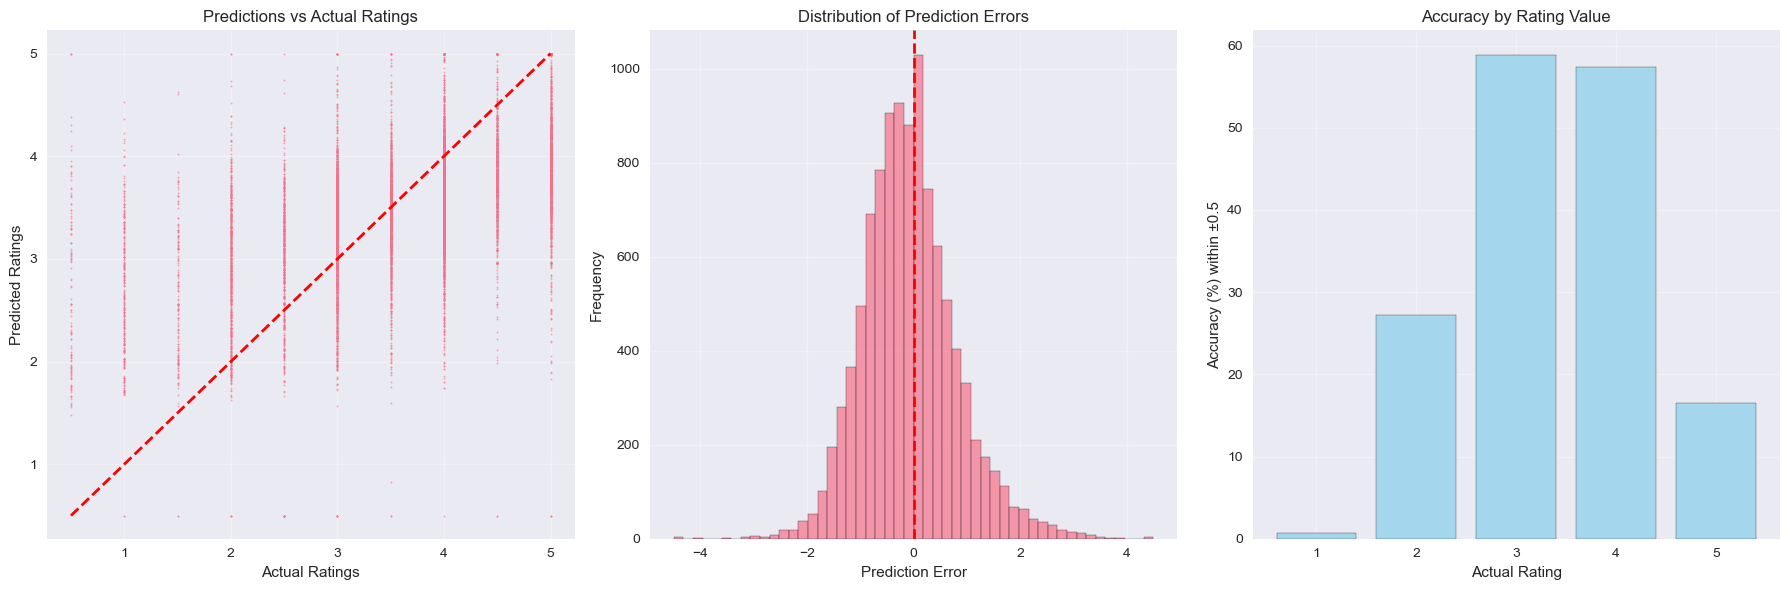

Post-evaluation MPS cache cleared!


In [39]:
# Evaluate on test set with MPS
print("Evaluating on Test Set with MPS...")
print("=" * 50)

# Make sure model is on the right device
model = model.to(device)

test_loss, test_metrics, test_predictions, test_targets = evaluate(model, test_loader, nn.MSELoss(), device)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test RMSE: {test_metrics['RMSE']:.4f}")
print(f"Test MAE: {test_metrics['MAE']:.4f}")
print(f"Test Accuracy (±0.5 stars): {test_metrics['Accuracy_0.5']:.2f}%")
print(f"Test Accuracy (±1.0 stars): {test_metrics['Accuracy_1.0']:.2f}%")

# Rest of your plotting code remains the same...
# Plot test results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Predictions vs Actual scatter plot
axes[0].scatter(test_targets.cpu().numpy(), test_predictions.cpu().numpy(), alpha=0.5, s=1)
axes[0].plot([0.5, 5], [0.5, 5], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Ratings')
axes[0].set_ylabel('Predicted Ratings')
axes[0].set_title('Predictions vs Actual Ratings')
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = (test_predictions - test_targets).cpu().numpy()
axes[1].hist(errors, bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].grid(True, alpha=0.3)

# Accuracy by rating value
rating_accuracies = []
rating_values = []
for rating in [1.0, 2.0, 3.0, 4.0, 5.0]:
    mask = (test_targets == rating)
    if mask.sum() > 0:
        accuracy = (torch.abs(test_predictions[mask] - test_targets[mask]) <= 0.5).float().mean() * 100
        rating_accuracies.append(accuracy.cpu().item())
        rating_values.append(rating)

axes[2].bar(rating_values, rating_accuracies, alpha=0.7, color='skyblue', edgecolor='black')
axes[2].set_xlabel('Actual Rating')
axes[2].set_ylabel('Accuracy (%) within ±0.5')
axes[2].set_title('Accuracy by Rating Value')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clear MPS cache after evaluation
if device.type == 'mps':
    torch.mps.empty_cache()
    print("Post-evaluation MPS cache cleared!")


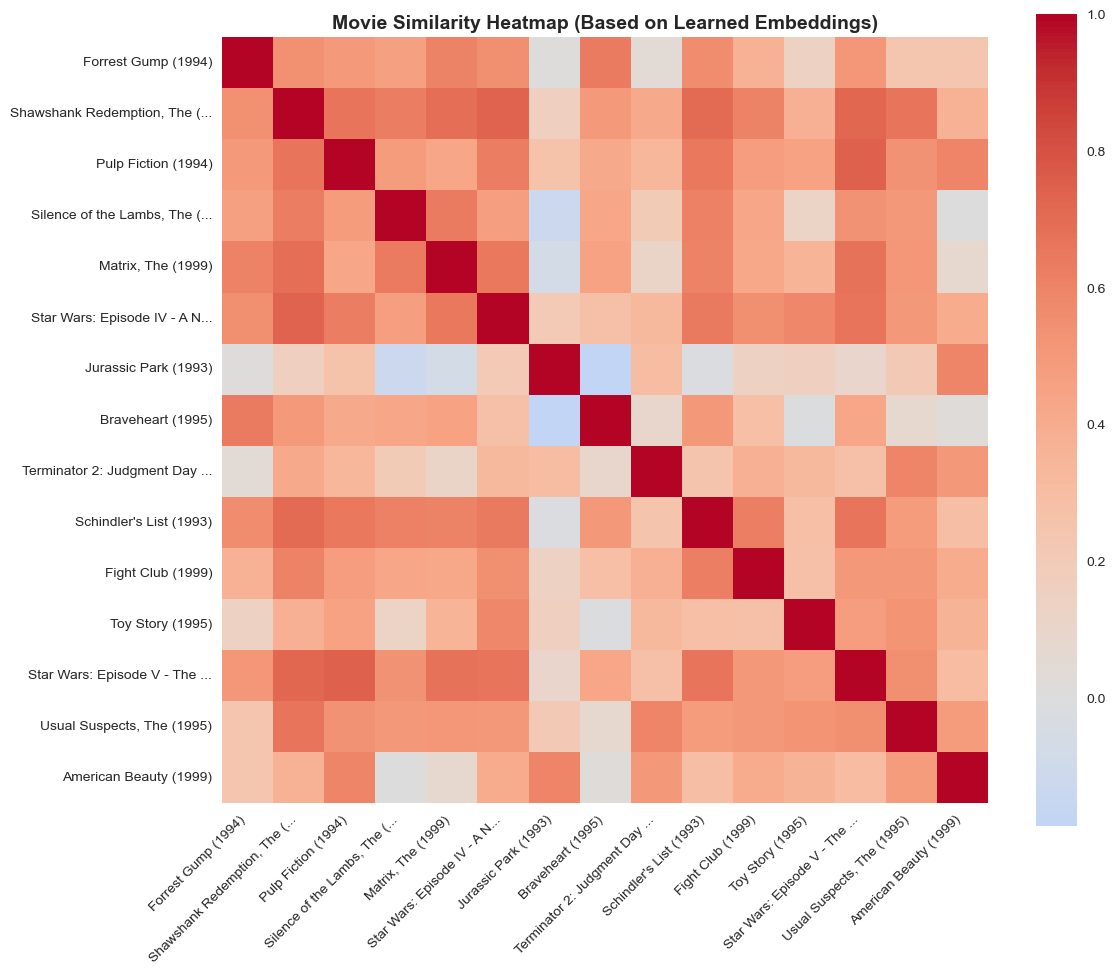


TRAINING COMPLETE! 🎬
Final Test RMSE: 0.8832
Final Test Accuracy (±0.5): 46.49%
Model Parameters: 699,040


In [41]:
def analyze_embeddings(model, idx_to_movie, df, top_k=10):
    """Analyze learned movie embeddings"""
    model.eval()
    
    # Get movie embeddings
    movie_embeddings = model.movie_embedding.weight.data.cpu().numpy()
    
    # Calculate similarity matrix for a sample of movies
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Get popular movies (movies with many ratings)
    movie_counts = df.groupby('movieId').size().sort_values(ascending=False)
    popular_movies = movie_counts.head(50).index.tolist()
    
    # Map to indices
    popular_movie_indices = [movie_to_idx[mid] for mid in popular_movies if mid in movie_to_idx]
    
    if len(popular_movie_indices) > 10:
        # Calculate similarities
        popular_embeddings = movie_embeddings[popular_movie_indices]
        similarities = cosine_similarity(popular_embeddings)
        
        # Plot similarity heatmap
        plt.figure(figsize=(12, 10))
        
        # Get movie titles for the heatmap
        movie_titles = []
        for idx in popular_movie_indices[:15]:  # Limit to 15 for readability
            movie_id = idx_to_movie[idx]
            title = df[df['movieId'] == movie_id]['title'].iloc[0]
            # Shorten title if too long
            if len(title) > 30:
                title = title[:27] + "..."
            movie_titles.append(title)
        
        # Create heatmap
        sns.heatmap(similarities[:15, :15], 
                   xticklabels=movie_titles, 
                   yticklabels=movie_titles,
                   cmap='coolwarm', 
                   center=0,
                   square=True,
                   fmt='.2f')
        plt.title('Movie Similarity Heatmap (Based on Learned Embeddings)', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

# Analyze the learned embeddings
analyze_embeddings(model, idx_to_movie, df)

# Print final summary
print("\n" + "="*60)
print("TRAINING COMPLETE! 🎬")
print("="*60)
print(f"Final Test RMSE: {test_metrics['RMSE']:.4f}")
print(f"Final Test Accuracy (±0.5): {test_metrics['Accuracy_0.5']:.2f}%")
print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("="*60)


In [43]:
def get_movie_recommendations(model, user_id, df, user_to_idx, movie_to_idx, idx_to_movie, device, top_k=10):
    """Get top-k movie recommendations for a user - MPS compatible"""
    model.eval()
    
    if user_id not in user_to_idx:
        print(f"User {user_id} not found in training data!")
        return []
    
    user_idx = user_to_idx[user_id]
    
    # Get movies the user hasn't rated
    user_movies = set(df[df['userId'] == user_id]['movieId'].values)
    all_movies = set(movie_to_idx.keys())
    unrated_movies = all_movies - user_movies
    
    if not unrated_movies:
        print(f"User {user_id} has rated all movies!")
        return []
    
    print(f"🎬 Generating recommendations for User {user_id}...")
    print(f"📊 Found {len(unrated_movies)} unrated movies to evaluate")
    
    # Predict ratings for unrated movies
    predictions = []
    
    with torch.no_grad():
        for i, movie_id in enumerate(unrated_movies):
            movie_idx = movie_to_idx[movie_id]
            
            # CREATE TENSORS ON THE CORRECT DEVICE (MPS)
            user_tensor = torch.LongTensor([user_idx]).to(device)
            movie_tensor = torch.LongTensor([movie_idx]).to(device)
            
            predicted_rating = model(user_tensor, movie_tensor).item()
            predictions.append((movie_id, predicted_rating))
            
            # Show progress for large datasets
            if i % 1000 == 0 and i > 0:
                print(f"   Processed {i}/{len(unrated_movies)} movies...")
    
    # Sort by predicted rating and get top-k
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_recommendations = predictions[:top_k]
    
    # Format recommendations with movie titles
    recommendations = []
    for movie_id, rating in top_recommendations:
        title = df[df['movieId'] == movie_id]['title'].iloc[0]
        genres = df[df['movieId'] == movie_id]['genres'].iloc[0]
        recommendations.append({
            'movieId': movie_id,
            'title': title,
            'genres': genres,
            'predicted_rating': rating
        })
    
    return recommendations

# FIXED: Get recommendations for User 1 (now with device parameter)
user_id = 1
recommendations = get_movie_recommendations(model, user_id, df, user_to_idx, movie_to_idx, idx_to_movie, device, top_k=10)

print(f"\n🌟 Top 10 Movie Recommendations for User {user_id}:")
print("=" * 80)
for i, rec in enumerate(recommendations, 1):
    print(f"{i:2d}. {rec['title']}")
    print(f"    ⭐ Predicted Rating: {rec['predicted_rating']:.2f}/5.0")
    print(f"    🎭 Genres: {rec['genres']}")
    print()

# Clear MPS cache after recommendations
if device.type == 'mps':
    torch.mps.empty_cache()
    print("🧹 MPS cache cleared after recommendations!")


🎬 Generating recommendations for User 1...
📊 Found 9492 unrated movies to evaluate
   Processed 1000/9492 movies...
   Processed 2000/9492 movies...
   Processed 3000/9492 movies...
   Processed 4000/9492 movies...
   Processed 5000/9492 movies...
   Processed 6000/9492 movies...
   Processed 7000/9492 movies...
   Processed 8000/9492 movies...
   Processed 9000/9492 movies...

🌟 Top 10 Movie Recommendations for User 1:
 1. Persuasion (1995)
    ⭐ Predicted Rating: 5.00/5.0
    🎭 Genres: Drama|Romance

 2. Saving Santa (2013)
    ⭐ Predicted Rating: 5.00/5.0
    🎭 Genres: Animation|Children|Comedy

 3. The Brain (1969)
    ⭐ Predicted Rating: 5.00/5.0
    🎭 Genres: Comedy|Crime

 4. Cry, the Beloved Country (1995)
    ⭐ Predicted Rating: 5.00/5.0
    🎭 Genres: Drama

 5. Lamerica (1994)
    ⭐ Predicted Rating: 5.00/5.0
    🎭 Genres: Adventure|Drama

 6. Postman, The (Postino, Il) (1994)
    ⭐ Predicted Rating: 5.00/5.0
    🎭 Genres: Comedy|Drama|Romance

 7. Antonia's Line (Antonia) (1